# JUG vs PINT Comparison

General-purpose comparison of JUG and PINT timing solutions.

Shows:
- Parameter comparison (value + uncertainty for each fitted param)
- Normalized distance |Δ|/σ per param, coloured by agreement level
- Post-fit residuals (both codes overlaid)
- Noise realizations per component (JUG, if noise-aware)
- Ridge consistency check for DDK near-circular orbits
- Chi² / WRMS / convergence diagnostics

In [1]:
import sys
sys.path.insert(0, '..')  # JUG root

# Source all functions from the comparison script
import importlib.util, pathlib
_spec = importlib.util.spec_from_file_location(
    'compare_jug_pint',
    pathlib.Path('..') / 'compare_jug_pint.py'
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
sys.modules['compare_jug_pint'] = _mod  # force fresh version, bypass stale cache

from compare_jug_pint import (
    get_fit_params_from_par, has_noise_model,
    detect_timescale, save_as_tdb_par, ensure_tdb_par,
    compute_prefit_residuals_jug, compute_prefit_residuals_pint,
    compute_correlation_matrix,
    run_jug_fit, run_pint_fit,
    print_comparison_table, _print_ridge_checks,
    _normalized_distance, _sigma_color, _categorize_param,
    DEGENERATE_PARAMS, ANGLE_PARAMS, PARAM_CATEGORIES,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Configuration

In [2]:
# ── Edit these ──────────────────────────────────────────────────────────────
PAR_RAW = Path('/home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1713+0747ao_PINT_20220306.nb.par')
TIM = Path('/home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1713+0747ao_PINT_20220306.nb.tim')

# Clock dir — set to None to use JUG built-in clocks
#CLOCK_DIR = '/home/mattm/soft/JUG/data/pulsars/NG_data/NANOGrav15yr_PulsarTiming_v2.1.0/clock'
CLOCK_DIR = None  # set to path above to use NG clock files

# Noise model: True = GLS (noise-aware), False = WLS, None = auto-detect from par
USE_NOISE = True

# Override fit params (None = read from par file)
FIT_PARAMS_OVERRIDE = None
# e.g. FIT_PARAMS_OVERRIDE = ['F0', 'F1', 'RAJ', 'DECJ', 'A1', 'KIN', 'KOM']
# ────────────────────────────────────────────────────────────────────────────

# Auto-detect timescale and convert TCB → TDB if needed
ts = detect_timescale(PAR_RAW)
print(f'Detected timescale: {ts}')
if ts == 'TCB':
    PAR = save_as_tdb_par(PAR_RAW)
    print(f'Converted to TDB: {PAR}')
else:
    PAR = PAR_RAW
    print(f'Using par as-is: {PAR}')

# Resolve noise setting
use_noise = USE_NOISE if USE_NOISE is not None else has_noise_model(PAR)

# Resolve fit params
if FIT_PARAMS_OVERRIDE:
    fit_params = FIT_PARAMS_OVERRIDE
else:
    fit_params = get_fit_params_from_par(PAR)

print(f'\nPar:        {PAR}')
print(f'Tim:        {TIM}')
#print(f'Clock dir:  {CLOCK_DIR}')
print(f'Noise:      {"GLS" if use_noise else "WLS (noise-free)"}')
print(f'Fit params ({len(fit_params)}): {fit_params}')

Detected timescale: TDB
Using par as-is: /home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1713+0747ao_PINT_20220306.nb.par

Par:        /home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1713+0747ao_PINT_20220306.nb.par
Tim:        /home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1713+0747ao_PINT_20220306.nb.tim
Noise:      GLS
Fit params (313): ['ELONG', 'ELAT', 'PMELONG', 'PMELAT', 'PX', 'F0', 'F1', 'DMX_0001', 'DMX_0002', 'DMX_0003', 'DMX_0004', 'DMX_0005', 'DMX_0006', 'DMX_0007', 'DMX_0008', 'DMX_0009', 'DMX_0010', 'DMX_0011', 'DMX_0012', 'DMX_0013', 'DMX_0014', 'DMX_0015', 'DMX_0016', 'DMX_0017', 'DMX_0018', 'DMX_0019', 'DMX_0020', 'DMX_0021', 'DMX_0022', 'DMX_0023', 'DMX_0024', 'DMX_0025', 'DMX_0026', 'DMX_0027', 'DMX_0028', 'DMX_0029', 'DMX_0030', 'DMX_0031', 'DMX_0032', 'DMX_0033', 'DMX_0034', 'DMX_0035', 'DMX_0036', 'DMX_0037', 'DMX_0038', 'DMX_0039', 'DMX_0040', 'DMX_0041', 'DMX_0042', 'DMX_0043', 'DMX_0044', 'DMX_0045', 'DMX_0046', 'DMX_0047', 'DMX_0

## Pre-fit Residuals: Physics Model Agreement Check

Before comparing fitted solutions, verify that JUG and PINT compute the **same residuals from the same par file values** (no fitting). If pre-fit residuals agree → physics model is consistent, differences in post-fit params are due to optimizer convergence. If they disagree → physics model bug (delays differ between codes).

Computing JUG pre-fit residuals (no fitting)...
[!] Unrecognized par file parameters (ignored by JUG): CHI2, CLOCK, DMDATA, ECL
  JUG  pre-fit WRMS = 0.269600 µs  [2.86s]
Computing PINT pre-fit residuals (no fitting)...


2026-04-22 15:41:30.454 | DEBUG    | pint.models.binary_ddk:validate:211 - Validating DDK model in ECL coordinates
2026-04-22 15:41:32.767 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-04-22 15:41:33.160 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-04-22 15:41:33.160 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-04-22 15:41:33.162 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-04-22 15:41:33.163 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/home/mattm/.astropy/cache/download/url/d3c81b5766f4bfb84e65504c8a453085/contents) with bogus_last_correction=False
2026-04-22 15:41:33.171 | INFO     | pint.observatory:find

  PINT pre-fit WRMS = 0.270031 µs  [9.10s]

  ΔWRMS (pre-fit) = 0.432 ns
  ⏱  Data load+eval: JUG 2.86s  PINT 9.10s  → JUG faster by 3.2x


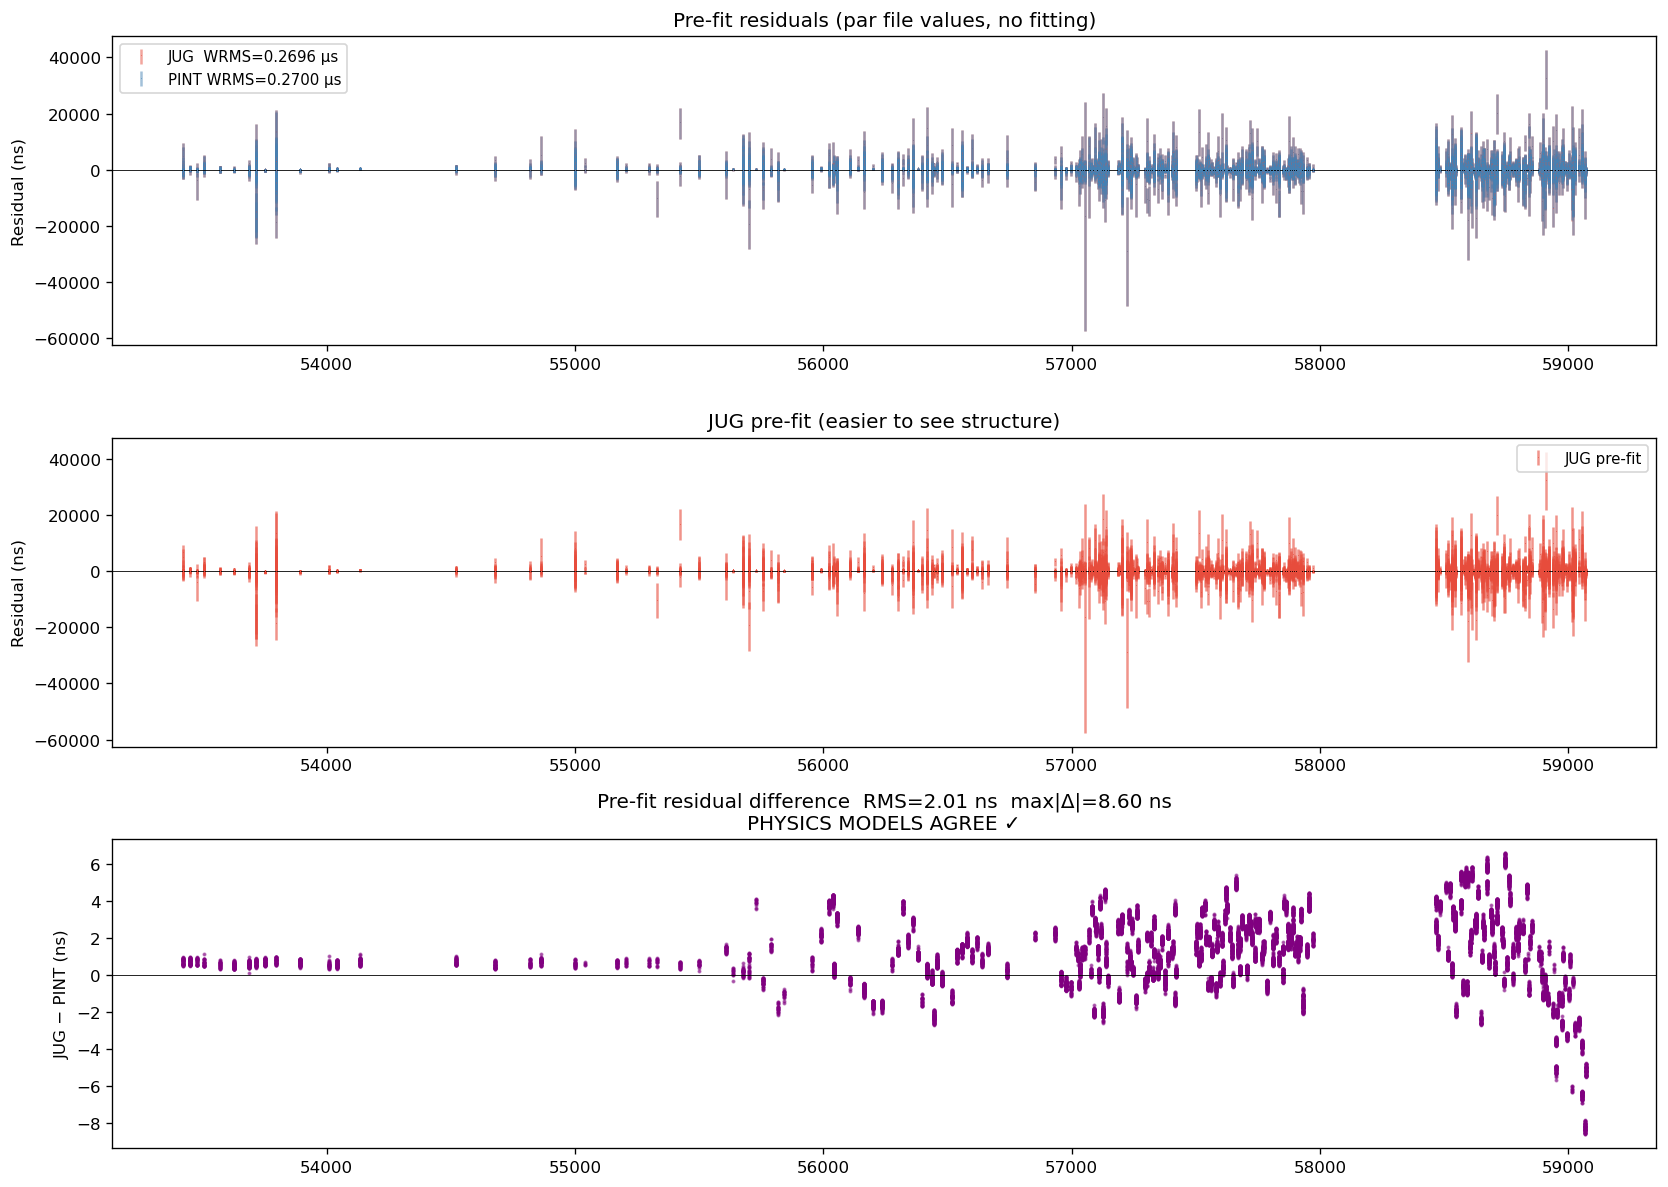


Diagnosis:
  ⚠ Pre-fit residual RMS diff = 2.01 ns — small physics discrepancy
    → Possible: clock corrections, PLANET_SHAPIRO, or timescale difference


In [3]:
import logging, warnings, time
logging.getLogger('pint').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

print('Computing JUG pre-fit residuals (no fitting)...')
_t0 = time.perf_counter()
prefit_jug = compute_prefit_residuals_jug(PAR, TIM, clock_dir=CLOCK_DIR)
_t_jug_prefit = time.perf_counter() - _t0
print(f'  JUG  pre-fit WRMS = {prefit_jug["wrms_us"]:.6f} µs  [{_t_jug_prefit:.2f}s]')

print('Computing PINT pre-fit residuals (no fitting)...')
_t0 = time.perf_counter()
prefit_pint = compute_prefit_residuals_pint(PAR, TIM, clock_dir=CLOCK_DIR)
_t_pint_prefit = time.perf_counter() - _t0
print(f'  PINT pre-fit WRMS = {prefit_pint["wrms_us"]:.6f} µs  [{_t_pint_prefit:.2f}s]')

prefit_diff_ns = abs(prefit_jug['wrms_us'] - prefit_pint['wrms_us']) * 1000
print(f'\n  ΔWRMS (pre-fit) = {prefit_diff_ns:.3f} ns')

_faster_prefit = 'JUG' if _t_jug_prefit < _t_pint_prefit else 'PINT'
_ratio_prefit = max(_t_jug_prefit, _t_pint_prefit) / max(min(_t_jug_prefit, _t_pint_prefit), 1e-9)
print(f'  ⏱  Data load+eval: JUG {_t_jug_prefit:.2f}s  PINT {_t_pint_prefit:.2f}s  → {_faster_prefit} faster by {_ratio_prefit:.1f}x')

prefit_mjd_aligned = (len(prefit_jug['tdb_mjd']) == len(prefit_pint['tdb_mjd']) and
                      len(prefit_jug['tdb_mjd']) > 0 and
                      np.allclose(prefit_jug['tdb_mjd'], prefit_pint['tdb_mjd'], atol=1e-9))

fig, axes = plt.subplots(3 if prefit_mjd_aligned else 2, 1,
                          figsize=(14, 10), sharex=False)

ax = axes[0]
ax.errorbar(prefit_jug['tdb_mjd'], prefit_jug['residuals_us'] * 1e3,
            yerr=prefit_jug['errors_us'] * 1e3, fmt=',', alpha=0.5,
            color='#e74c3c', label=f'JUG  WRMS={prefit_jug["wrms_us"]:.4f} µs')
ax.errorbar(prefit_pint['tdb_mjd'], prefit_pint['residuals_us'] * 1e3,
            yerr=prefit_pint['errors_us'] * 1e3, fmt=',', alpha=0.5,
            color='steelblue', label=f'PINT WRMS={prefit_pint["wrms_us"]:.4f} µs')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Residual (ns)')
ax.set_title('Pre-fit residuals (par file values, no fitting)')
ax.legend(fontsize=9)

ax = axes[1]
ax.errorbar(prefit_jug['tdb_mjd'], prefit_jug['residuals_us'] * 1e3,
            yerr=prefit_jug['errors_us'] * 1e3, fmt=',', alpha=0.6,
            color='#e74c3c', label='JUG pre-fit')
ax.set_ylabel('Residual (ns)')
ax.set_title('JUG pre-fit (easier to see structure)')
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.5)

if prefit_mjd_aligned:
    diff = (prefit_jug['residuals_us'] - prefit_pint['residuals_us']) * 1e3
    ax = axes[2]
    ax.scatter(prefit_jug['tdb_mjd'], diff, s=2, alpha=0.5, color='purple')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('JUG − PINT (ns)')
    ax.set_title(f'Pre-fit residual difference  RMS={np.std(diff):.2f} ns  '
                 f'max|Δ|={np.max(np.abs(diff)):.2f} ns\n'
                 f'{"PHYSICS MODELS AGREE ✓" if np.std(diff) < 10 else "PHYSICS MODEL MISMATCH — investigate delay components"}')

fig.tight_layout()
plt.show()

print()
print('Diagnosis:')
if prefit_mjd_aligned:
    rms_diff = np.std(diff)
    if rms_diff < 1.0:
        print(f'  ✓ Pre-fit residuals agree to {rms_diff:.2f} ns RMS — physics models identical')
        print('    → Post-fit parameter differences are due to optimizer convergence / degeneracy')
    elif rms_diff < 100:
        print(f'  ⚠ Pre-fit residual RMS diff = {rms_diff:.2f} ns — small physics discrepancy')
        print('    → Possible: clock corrections, PLANET_SHAPIRO, or timescale difference')
    else:
        print(f'  ✗ Pre-fit residual RMS diff = {rms_diff:.2f} ns — SIGNIFICANT physics mismatch')
        print('    → Check: binary model (DDK vs T2), timescale (TCB/TDB), DILATEFREQ, TIMEEPH')
else:
    print('  Cannot diff residuals: TOA arrays not aligned')


## Run Fits

In [4]:
import logging, warnings, time
logging.getLogger('pint').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

print('Running JUG fit...')
_t0 = time.perf_counter()
jug = run_jug_fit(PAR, TIM, fit_params, clock_dir=CLOCK_DIR, verbose=False)
_t_jug_fit = time.perf_counter() - _t0
print(f'  JUG  WRMS = {jug["wrms_us"]:.6f} µs  '
      f'(converged={jug["converged"]}, iter={jug["iterations"]})  [{_t_jug_fit:.2f}s]')

print('Running PINT fit...')
_t0 = time.perf_counter()
pint_r = run_pint_fit(PAR, TIM, fit_params, gls=use_noise,
                      clock_dir=CLOCK_DIR, verbose=False)
_t_pint_fit = time.perf_counter() - _t0
print(f'  PINT WRMS = {pint_r["wrms_us"]:.6f} µs  [{_t_pint_fit:.2f}s]')

wrms_diff_ns = abs(jug['wrms_us'] - pint_r['wrms_us']) * 1000
print(f'  ΔWRMS     = {wrms_diff_ns:.3f} ns')

_faster_fit = 'JUG' if _t_jug_fit < _t_pint_fit else 'PINT'
_ratio_fit = max(_t_jug_fit, _t_pint_fit) / max(min(_t_jug_fit, _t_pint_fit), 1e-9)
print(f'\n  ⏱  Fit timing: JUG {_t_jug_fit:.2f}s  PINT {_t_pint_fit:.2f}s  → {_faster_fit} faster by {_ratio_fit:.1f}x')
if jug['iterations'] and _t_jug_fit > 0:
    print(f'       JUG {_t_jug_fit/jug["iterations"]:.2f}s/iter  ({jug["iterations"]} iters)')


Running JUG fit...
[!] Unrecognized par file parameters (ignored by JUG): CHI2, CLOCK, DMDATA, ECL
[SETUP] Building RED NOISE basis: 60 columns


2026-04-22 15:41:49.300 | DEBUG    | pint.models.binary_ddk:validate:211 - Validating DDK model in ECL coordinates


  JUG  WRMS = 0.114217 µs  (converged=True, iter=6)  [9.08s]
Running PINT fit...


2026-04-22 15:41:51.483 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-04-22 15:41:51.934 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-04-22 15:41:51.935 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2019) clock correction (~27 us)
2026-04-22 15:41:51.936 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-04-22 15:41:54.254 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-04-22 15:41:54.255 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-04-22 15:41:55.211 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-04-22 15:41:55.211 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-04-22 15:41:55.331 | I

  PINT WRMS = 0.193934 µs  [139.95s]
  ΔWRMS     = 79.717 ns

  ⏱  Fit timing: JUG 9.08s  PINT 139.95s  → JUG faster by 15.4x
       JUG 1.51s/iter  (6 iters)


## Parameter Comparison Table

In [5]:
print_comparison_table(jug, pint_r, fit_params)


Param                     JUG value          JUG σ             PINT value         PINT σ    |Δ|/σ  Notes
  ELONG                 256.6686992       2.64e-09            256.6686992       2.64e-09     0.02  
  ELAT                  30.70035825      5.018e-09            30.70035825      5.019e-09     0.00  
  PMELONG               5.260846515       0.001914             5.26086885       0.001914     0.01  
  PMELAT               -3.446017808       0.004121           -3.445950724       0.004121     0.02  
  PX                   0.8240835374        0.02068           0.8240956316        0.02068     0.00  DEG
  F0                    218.8118438      5.048e-14            218.8118438      5.049e-14     0.00  
  F1               -4.083928573e-16      1.816e-21       -4.083928877e-16      1.816e-21     0.02  
  DMX_0001                        —              —                      —              —        —  missing in one code
  DMX_0002                        —              —                      

## Summary Statistics

In [6]:
dists = []
for p in fit_params:
    if p in ANGLE_PARAMS:
        continue
    jv = jug['params'].get(p)
    pv = pint_r['params'].get(p)
    pu = pint_r['uncertainties'].get(p, 0.0)
    if jv is not None and pv is not None and pu > 0:
        dists.append((p, _normalized_distance(jv, pv, pu),
                      p in DEGENERATE_PARAMS))

ok    = sum(1 for _, d, _ in dists if d < 1.0)
warn  = sum(1 for _, d, _ in dists if 1.0 <= d < 3.0)
bad   = sum(1 for _, d, _ in dists if 3.0 <= d < 10.0)
drift = sum(1 for _, d, _ in dists if d >= 10.0)

non_deg_bad = [(p, d) for p, d, deg in dists if d >= 3.0 and not deg]

print(f'|Δ|/σ_PINT breakdown:')
print(f'  <1σ:    {ok}')
print(f'  1-3σ:   {warn}')
print(f'  3-10σ:  {bad}')
print(f'  >10σ:   {drift}')
if non_deg_bad:
    print(f'\nNon-degenerate params with |Δ|>3σ (potential bugs):')
    for p, d in sorted(non_deg_bad, key=lambda x: -x[1]):
        print(f'  {p:12s} {d:.1f}σ')

|Δ|/σ_PINT breakdown:
  <1σ:    19
  1-3σ:   0
  3-10σ:  0
  >10σ:   0


## Why Do Parameters Differ? — Correlation & Condition Analysis

Large |Δ|/σ with matching WRMS = **degenerate manifold** (multiple valid solutions).  
The correlation matrix shows *which params move together*, explaining apparent large shifts.

In [7]:
# ── Condition number and correlation matrix from JUG's covariance ─────────
cov = jug.get('covariance')
cov_fit_params = [p for p in fit_params
                  if p not in ANGLE_PARAMS
                  and jug['uncertainties'].get(p, 0) > 0]

if cov is not None and len(cov) > 0:
    # Condition number
    cond = np.linalg.cond(cov)
    print(f'JUG covariance matrix condition number: {cond:.3e}')
    if cond > 1e10:
        print('  → HIGHLY ILL-CONDITIONED: degenerate directions exist')
        print('    Parameters with large shifts can move along flat directions')
        print('    without changing χ² — this explains large |Δ|/σ vs PINT')
    elif cond > 1e6:
        print('  → Moderately ill-conditioned: some degeneracy present')
    else:
        print('  → Well-conditioned: parameter differences are genuine')

    # Full correlation matrix (subset: non-angle params with nonzero uncertainty)
    n = len(cov_fit_params)
    if n > 0 and cov.shape[0] >= n:
        cov_sub = cov[:n, :n]  # assumes fit_params order matches cov
        corr, _ = compute_correlation_matrix(cov_sub, cov_fit_params)

        # Plot: focus on params with high correlations
        fig, ax = plt.subplots(figsize=(max(8, n * 0.4), max(7, n * 0.38)))
        im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, label='Correlation')
        ax.set_xticks(range(n))
        ax.set_xticklabels(cov_fit_params, rotation=90, fontsize=7)
        ax.set_yticks(range(n))
        ax.set_yticklabels(cov_fit_params, fontsize=7)
        ax.set_title('JUG parameter correlation matrix\n'
                     'Red=+1 (move together), Blue=−1 (anti-correlated)')

        # Annotate cells with |corr| > 0.7
        for i in range(n):
            for j in range(n):
                if i != j and abs(corr[i, j]) > 0.7:
                    ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                            fontsize=5, color='white' if abs(corr[i,j]) > 0.9 else 'black')
        fig.tight_layout()
        plt.show()

        # Print strongly correlated pairs
        pairs = []
        for i in range(n):
            for j in range(i+1, n):
                if abs(corr[i, j]) > 0.8:
                    pairs.append((cov_fit_params[i], cov_fit_params[j], corr[i, j]))
        if pairs:
            print('\nStrongly correlated pairs (|r| > 0.8):')
            for p1, p2, r in sorted(pairs, key=lambda x: -abs(x[2])):
                print(f'  {p1:12s} ↔ {p2:12s}  r={r:+.4f}')
        else:
            print('\nNo strongly correlated pairs (|r| > 0.8)')
else:
    print('Covariance matrix not available in JUG result.')

Covariance matrix not available in JUG result.


In [8]:
# ── Systematic diagnosis of large parameter differences ──────────────────

print('═' * 70)
print('PARAMETER DIFFERENCE DIAGNOSIS')
print('═' * 70)

# 1. Check pre-fit residual agreement (physics model)
if 'prefit_jug' in dir() and 'prefit_pint' in dir():
    pf_jug_wrms = prefit_jug['wrms_us']
    pf_pint_wrms = prefit_pint['wrms_us']
    pf_diff = abs(pf_jug_wrms - pf_pint_wrms) * 1000
    print(f'\n[1] Physics model agreement (pre-fit WRMS diff): {pf_diff:.2f} ns')
    if pf_diff < 10:
        print('    ✓ Both codes compute same delays — physics OK')
        print('    → Differences are purely from optimizer / degeneracy')
    else:
        print(f'    ✗ {pf_diff:.0f} ns pre-fit mismatch — delay bug somewhere')
        print('    → Check: binary model type, PLANET_SHAPIRO, DILATEFREQ,')
        print('              clock corrections, FD delay convention')

# 2. WRMS match post-fit
print(f'\n[2] Post-fit WRMS: JUG={jug["wrms_us"]:.6f} PINT={pint_r["wrms_us"]:.6f} '
      f'Δ={abs(jug["wrms_us"]-pint_r["wrms_us"])*1e3:.2f} ns')
if abs(jug['wrms_us'] - pint_r['wrms_us']) * 1e3 < 1.0:
    print('    ✓ Both codes find same χ² minimum — both solutions valid')
else:
    print('    ⚠ WRMS differs — one code found better minimum than the other')

# 3. Condition number interpretation
if cov is not None:
    cond_val = np.linalg.cond(cov)
    print(f'\n[3] Covariance condition number: {cond_val:.2e}')
    if cond_val > 1e12:
        print('    ✗ SINGULAR covariance — degenerate parameters present')
        print('    → KOM/KIN/T0/OM/PB/OMDOT form a degenerate subspace')
        print('    → Both codes converge to valid solutions but at different')
        print('      ridge points; large σ-distance is expected')
    elif cond_val > 1e6:
        print('    ⚠ Ill-conditioned — some degeneracy in parameter space')

# 4. Identify which bad params are correlated with good params
bad_non_deg = [(p, _normalized_distance(jug['params'].get(p, 0),
                                         pint_r['params'].get(p, 0),
                                         pint_r['uncertainties'].get(p, 0)))
               for p in fit_params
               if p not in ANGLE_PARAMS and p not in DEGENERATE_PARAMS
               and jug['params'].get(p) is not None
               and pint_r['params'].get(p) is not None
               and _normalized_distance(jug['params'].get(p, 0),
                                        pint_r['params'].get(p, 0),
                                        pint_r['uncertainties'].get(p, 0)) > 3.0]

if bad_non_deg:
    print(f'\n[4] Non-degenerate params with |Δ|>3σ ({len(bad_non_deg)} params):')
    for p, d in sorted(bad_non_deg, key=lambda x: -x[1]):
        print(f'    {p:12s} {d:6.1f}σ')
    print('    → These may be pulled by correlation with degenerate params')
    print('      OR indicate a genuine physics/derivative bug')
    print('      Check pre-fit residuals first to distinguish the cases')
else:
    print('\n[4] ✓ All non-degenerate params agree within 3σ')

# 5. KIN specifically (key DDK observable)
kin_jug  = jug['params'].get('KIN')
kin_pint = pint_r['params'].get('KIN')
kin_unc  = pint_r['uncertainties'].get('KIN', 0)
if kin_jug is not None and kin_pint is not None and kin_unc > 0:
    kin_d = _normalized_distance(kin_jug, kin_pint, kin_unc)
    print(f'\n[5] KIN (orbital inclination): {kin_d:.1f}σ difference')
    print(f'    JUG={kin_jug:.6f}°  PINT={kin_pint:.6f}°  σ={kin_unc:.6f}°')
    if kin_d > 3:
        print('    ⚠ KIN differs significantly — key DDK angle')
        print('    → Could indicate different Kopeikin correction implementation')

print('\n' + '═' * 70)

══════════════════════════════════════════════════════════════════════
PARAMETER DIFFERENCE DIAGNOSIS
══════════════════════════════════════════════════════════════════════

[1] Physics model agreement (pre-fit WRMS diff): 0.43 ns
    ✓ Both codes compute same delays — physics OK
    → Differences are purely from optimizer / degeneracy

[2] Post-fit WRMS: JUG=0.114217 PINT=0.193934 Δ=79.72 ns
    ⚠ WRMS differs — one code found better minimum than the other

[4] ✓ All non-degenerate params agree within 3σ

[5] KIN (orbital inclination): 0.0σ difference
    JUG=109.741425°  PINT=109.713655°  σ=0.575379°

══════════════════════════════════════════════════════════════════════


## Parameter Comparison Plot

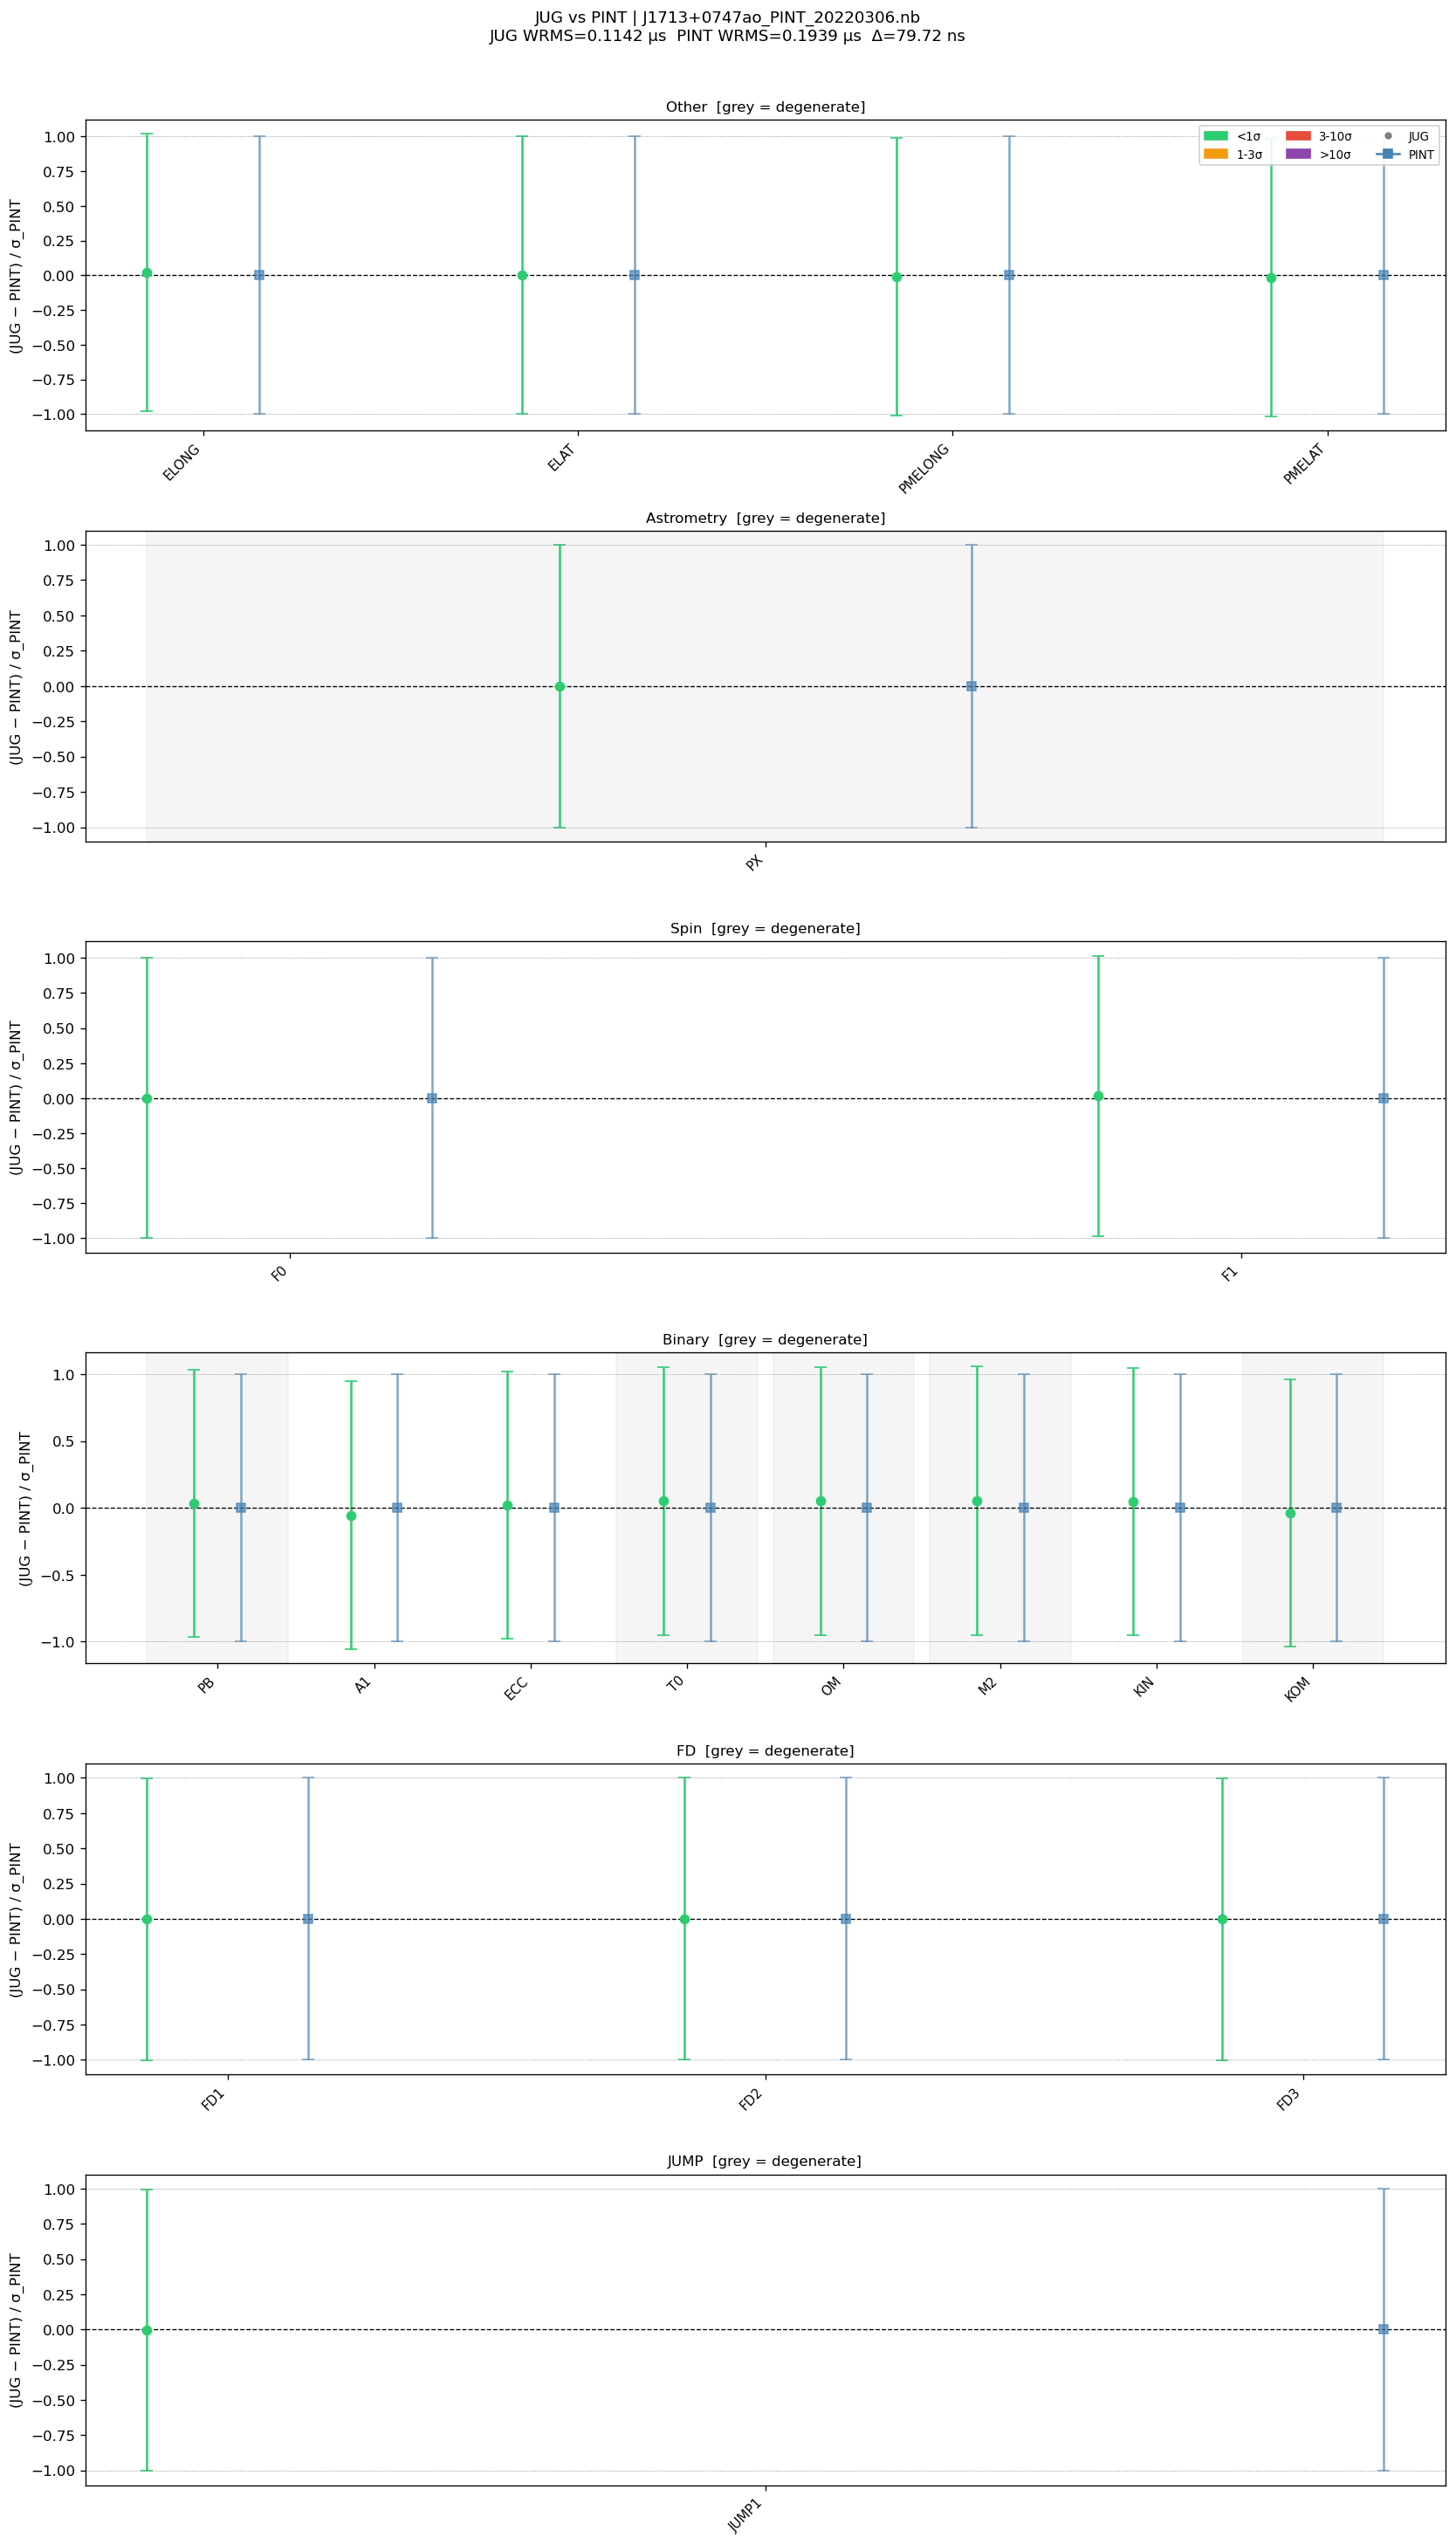

In [9]:
# Collect plottable params (numeric, both codes have value)
plottable = []
for p in fit_params:
    if p in ANGLE_PARAMS:
        continue
    jv = jug['params'].get(p)
    pv = pint_r['params'].get(p)
    ju = jug['uncertainties'].get(p, 0.0)
    pu = pint_r['uncertainties'].get(p, 0.0)
    if jv is None or pv is None:
        continue
    plottable.append((p, float(jv), float(ju), float(pv), float(pu),
                      _categorize_param(p)))

# Group by category
cats_present = []
cat_params = {}
for entry in plottable:
    cat = entry[5]
    if cat not in cat_params:
        cat_params[cat] = []
        cats_present.append(cat)
    cat_params[cat].append(entry)

n_cats = len(cats_present)
fig, axes = plt.subplots(n_cats, 1, figsize=(14, 4 * n_cats))
if n_cats == 1:
    axes = [axes]

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='<1σ'),
    mpatches.Patch(color='#f39c12', label='1-3σ'),
    mpatches.Patch(color='#e74c3c', label='3-10σ'),
    mpatches.Patch(color='#8e44ad', label='>10σ'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='JUG'),
    plt.Line2D([0], [0], marker='s', color='steelblue', label='PINT'),
]

for idx, (cat, ax) in enumerate(zip(cats_present, axes)):
    entries = cat_params[cat]
    n = len(entries)
    x = np.arange(n)
    labels = [e[0] for e in entries]

    for xi, (p, jv, ju, pv, pu, _) in enumerate(entries):
        dist = _normalized_distance(jv, pv, pu)
        col = _sigma_color(dist)
        ref_unc = pu if pu > 0 else ju
        if ref_unc == 0:
            continue
        jug_rel = (jv - pv) / ref_unc
        jug_err = ju / ref_unc
        pint_err = pu / ref_unc

        ax.errorbar(xi - 0.15, jug_rel,  yerr=jug_err,  fmt='o',
                    color=col, capsize=4, ms=6)
        ax.errorbar(xi + 0.15, 0.0, yerr=pint_err, fmt='s',
                    color='steelblue', capsize=4, ms=6, alpha=0.7)

        if np.isfinite(dist) and dist > 1.0:
            ax.annotate(f'{dist:.1f}σ',
                        (xi - 0.15, jug_rel + jug_err + abs(jug_rel) * 0.05 + 0.3),
                        fontsize=7, ha='center', color=col)

        if p in DEGENERATE_PARAMS:
            ax.axvspan(xi - 0.45, xi + 0.45, color='gray', alpha=0.08, zorder=0)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline(+1, color='gray', lw=0.5, ls=':')
    ax.axhline(-1, color='gray', lw=0.5, ls=':')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('(JUG − PINT) / σ_PINT')
    ax.set_title(f'{cat}  [grey = degenerate]', fontsize=10)
    if idx == 0:
        ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
                  ncol=3, framealpha=0.9)

fig.suptitle(
    f'JUG vs PINT | {PAR.stem}\n'
    f'JUG WRMS={jug["wrms_us"]:.4f} µs  PINT WRMS={pint_r["wrms_us"]:.4f} µs  '
    f'Δ={wrms_diff_ns:.2f} ns',
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.show()

## Residual Comparison

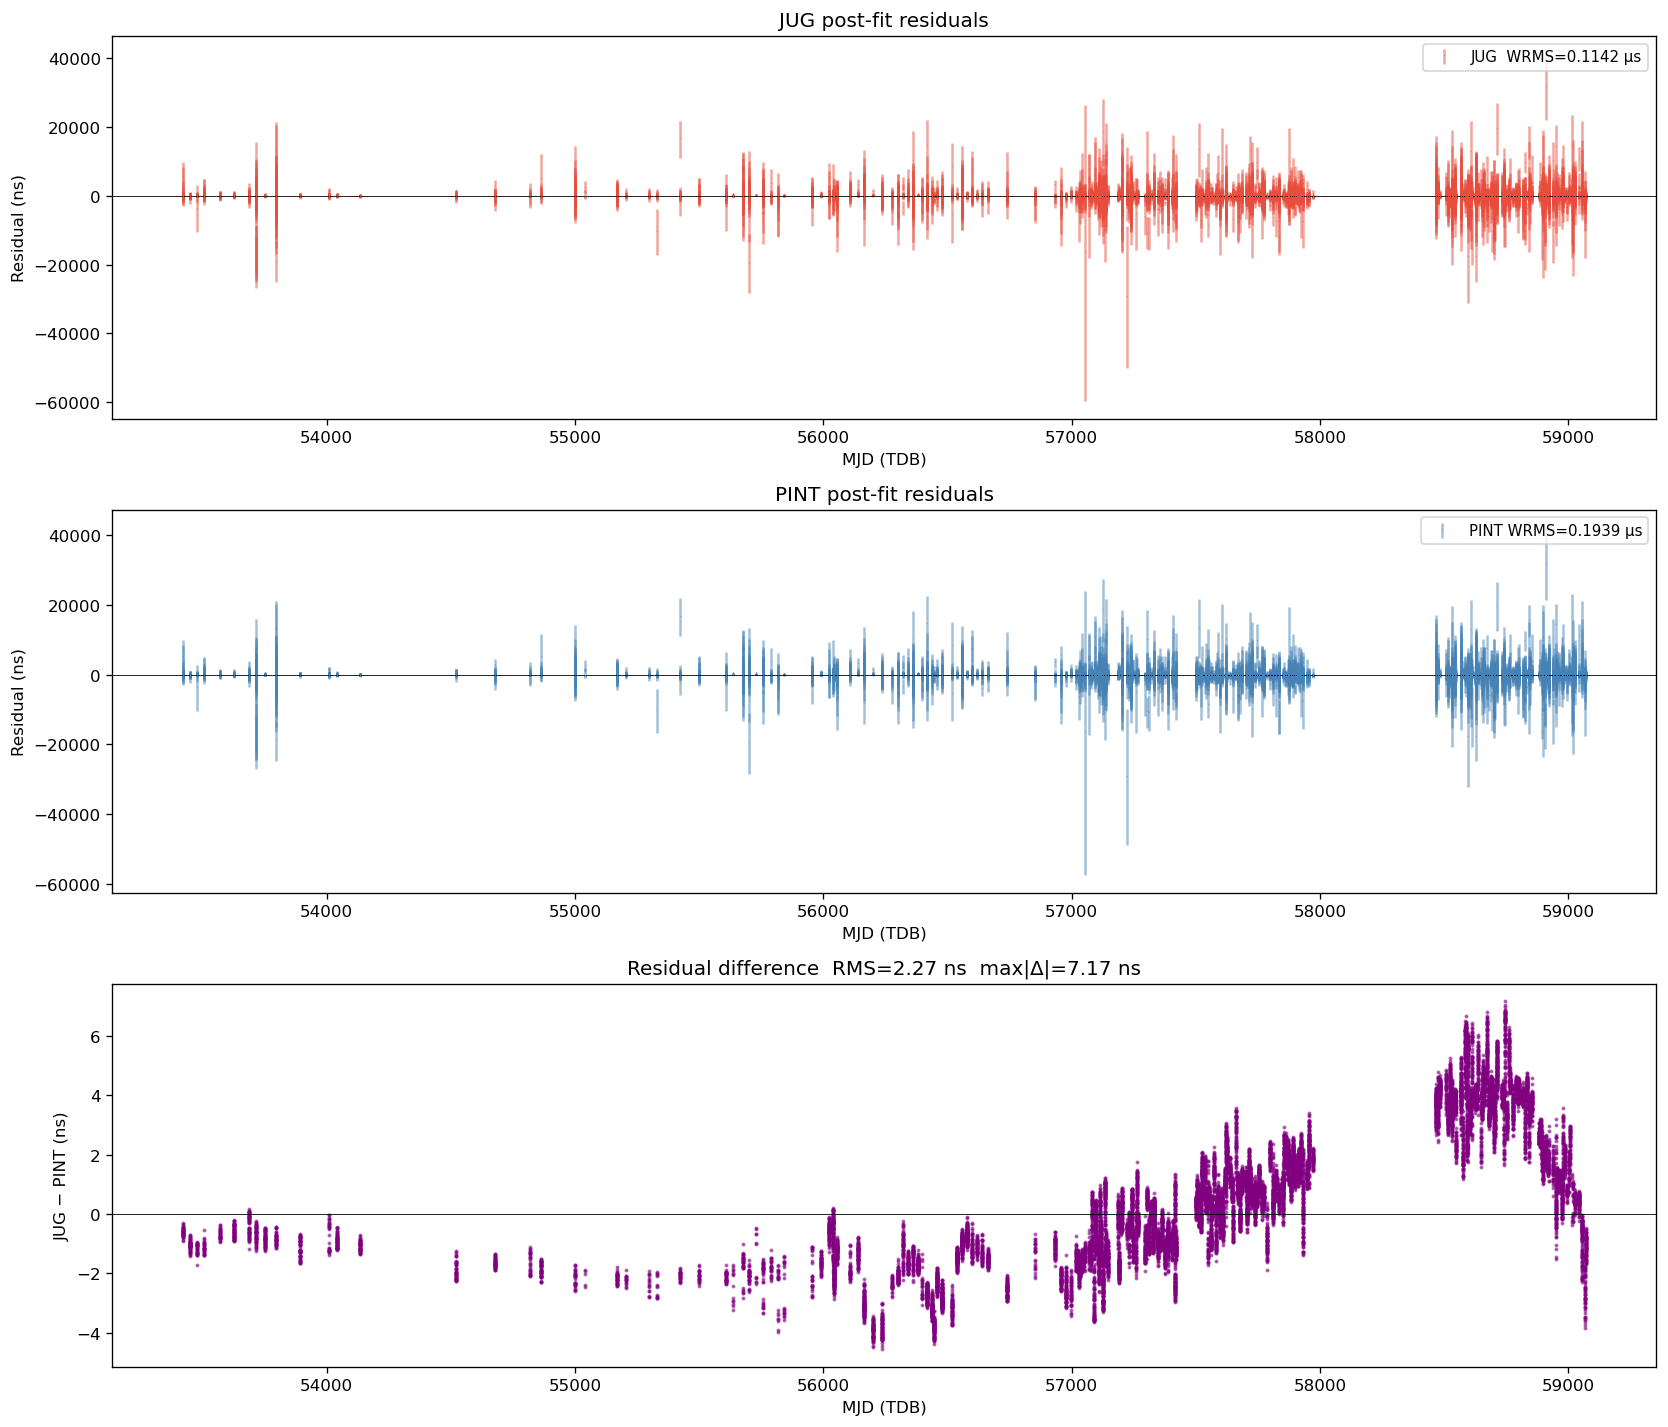

In [10]:
jug_mjd  = jug['tdb_mjd']
pint_mjd = pint_r['tdb_mjd']
jug_res  = jug['residuals_us'] * 1e3   # → ns
pint_res = pint_r['residuals_us'] * 1e3
jug_err  = jug['errors_us'] * 1e3
pint_err = pint_r['errors_us'] * 1e3

toas_aligned = (len(jug_mjd) == len(pint_mjd) and
                len(jug_mjd) > 0 and
                np.allclose(jug_mjd, pint_mjd, atol=1e-9))

n_rows = 3 if toas_aligned else 2
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4 * n_rows), sharex=False)

# Panel 0: JUG residuals
ax = axes[0]
ax.errorbar(jug_mjd, jug_res, yerr=jug_err, fmt=',', alpha=0.5,
            color='#e74c3c', label=f'JUG  WRMS={jug["wrms_us"]:.4f} µs')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Residual (ns)')
ax.set_xlabel('MJD (TDB)')
ax.set_title('JUG post-fit residuals')
ax.legend(fontsize=9)

# Panel 1: PINT residuals
ax = axes[1]
ax.errorbar(pint_mjd, pint_res, yerr=pint_err, fmt=',', alpha=0.5,
            color='steelblue', label=f'PINT WRMS={pint_r["wrms_us"]:.4f} µs')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Residual (ns)')
ax.set_xlabel('MJD (TDB)')
ax.set_title('PINT post-fit residuals')
ax.legend(fontsize=9)

# Panel 2: difference (only if TOAs are in same order)
if toas_aligned:
    diff_ns = jug_res - pint_res
    ax = axes[2]
    ax.scatter(jug_mjd, diff_ns, s=2, alpha=0.5, color='purple')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('JUG − PINT (ns)')
    ax.set_xlabel('MJD (TDB)')
    ax.set_title(f'Residual difference  RMS={np.std(diff_ns):.2f} ns  '
                 f'max|Δ|={np.max(np.abs(diff_ns)):.2f} ns')
else:
    print('TOA arrays not aligned — skipping difference panel.')

fig.tight_layout()
plt.show()

## Noise Realization Comparison

Only populated for noise-aware (GLS) fits. JUG exposes per-process noise realizations;
PINT does not — so we compare:
1. JUG noise realizations per component
2. Whitened (noise-subtracted) residuals from both codes

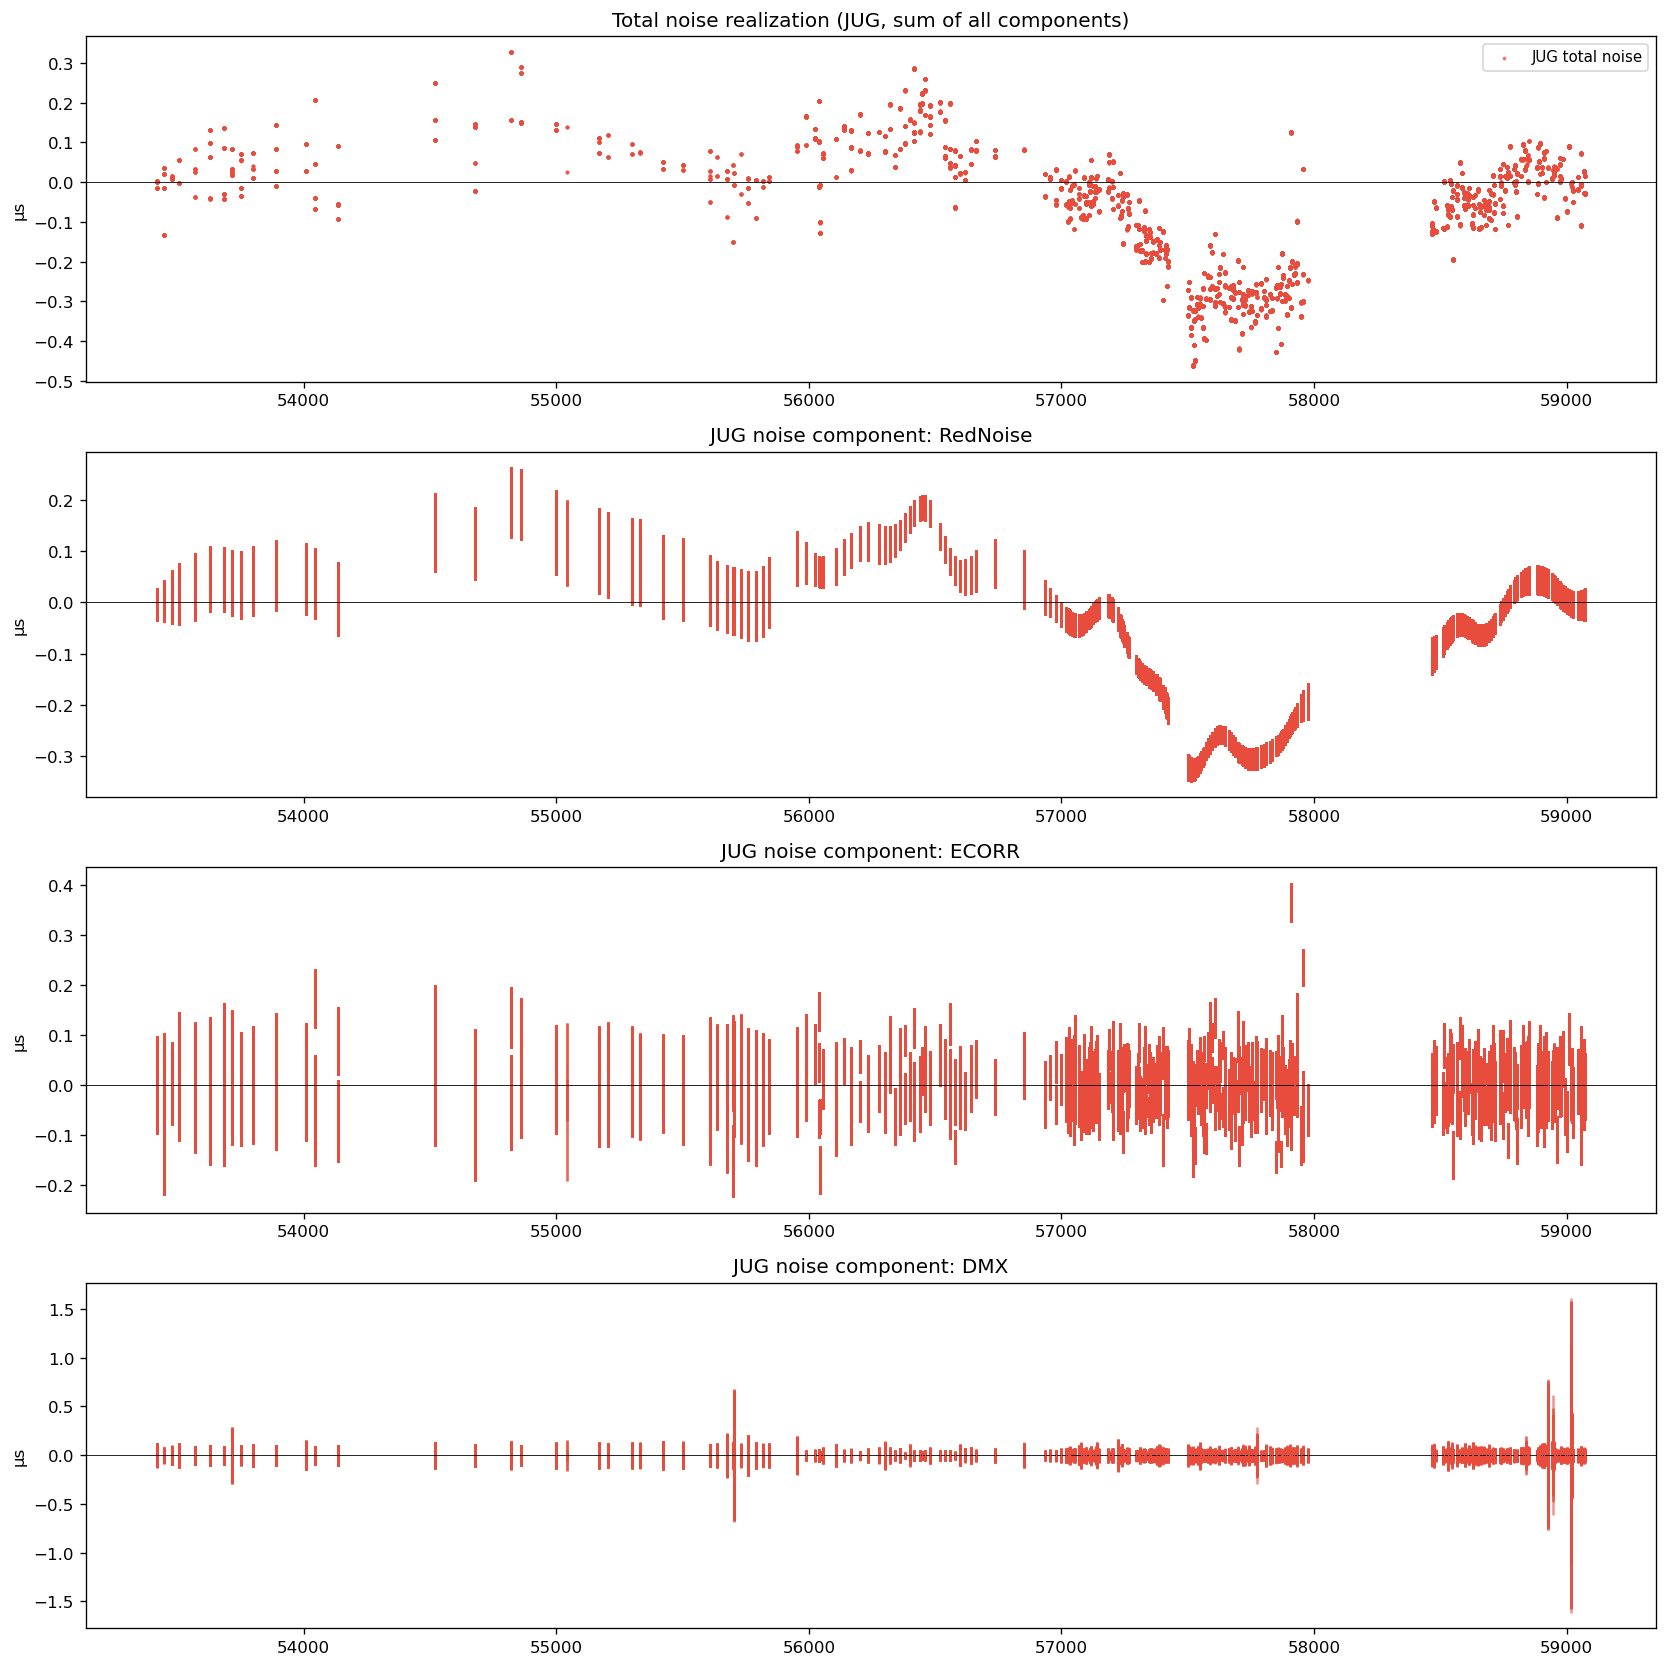

In [11]:
noise = {k: v for k, v in jug.get('noise_realizations', {}).items()
         if not k.endswith('_err')}

if not use_noise:
    print('Noise-free fit — no noise realizations to show.')
    print('Re-run with USE_NOISE = True and a noise par file.')
elif not noise:
    print('Noise-aware fit but no noise realizations returned.')
    print('Check that the par file has TNREDAMP/TNDMAMP/EFAC etc.')
else:
    n_comp = len(noise)
    fig, axes = plt.subplots(n_comp + 1, 1,
                             figsize=(14, 3.5 * (n_comp + 1)))
    if n_comp == 0:
        axes = [axes]

    # Panel 0: total noise realization (sum of all components)
    total_noise = np.zeros(len(jug_mjd))
    for label, vals in noise.items():
        if len(vals) == len(jug_mjd):
            total_noise += vals

    ax = axes[0]
    ax.scatter(jug_mjd, total_noise, s=2, alpha=0.6, color='#e74c3c',
               label='JUG total noise')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('µs')
    ax.set_title('Total noise realization (JUG, sum of all components)')
    ax.legend(fontsize=9)

    # Per-component panels
    for i, (label, vals) in enumerate(noise.items()):
        ax = axes[i + 1]
        err_key = label + '_err'
        errs = jug['noise_realizations'].get(err_key)
        if len(jug_mjd) == len(vals):
            if errs is not None:
                ax.errorbar(jug_mjd, vals, yerr=errs, fmt=',',
                            alpha=0.6, color='#e74c3c')
            else:
                ax.scatter(jug_mjd, vals, s=2, alpha=0.6, color='#e74c3c')
        ax.axhline(0, color='k', lw=0.5)
        ax.set_ylabel('µs')
        ax.set_title(f'JUG noise component: {label}')

    fig.tight_layout()
    plt.show()

## Noise-Subtracted Residuals (whitened)

For noise-aware fits: the post-fit residuals minus the total noise realization
should be white. Compare between JUG and PINT (PINT whitened = raw post-fit residuals
since PINT GLS uses the full noise covariance internally).

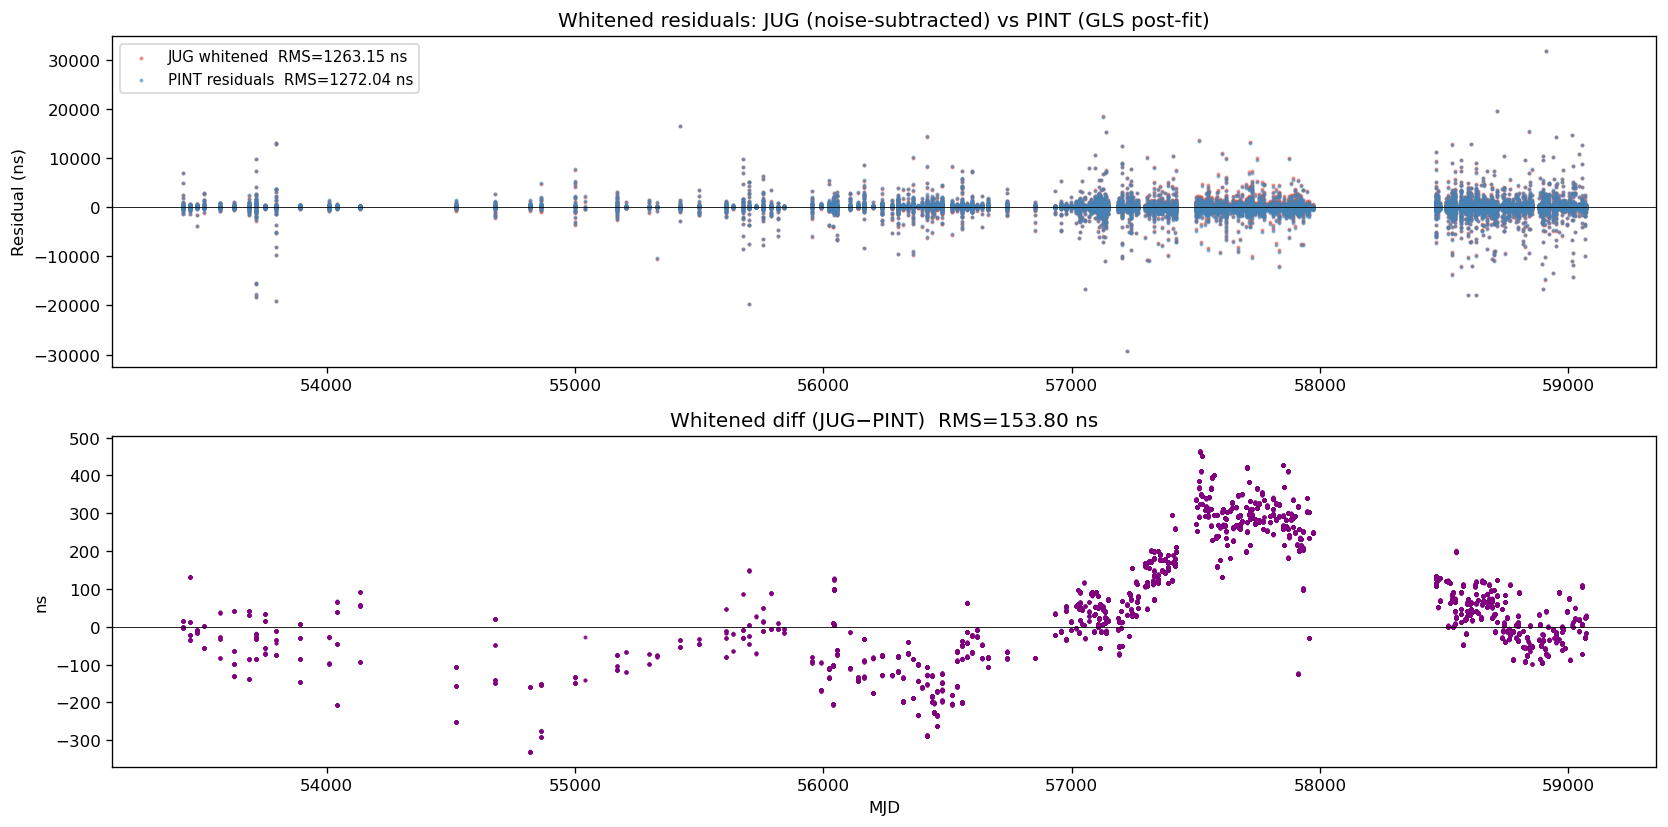

In [12]:
if not use_noise or not noise:
    print('Noise-free fit or no realizations — whitened comparison skipped.')
else:
    # jug_res is in ns; total_noise is in µs → convert to ns
    jug_whitened_ns = jug_res - total_noise * 1e3

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    ax = axes[0]
    if toas_aligned:
        ax.scatter(jug_mjd, jug_whitened_ns, s=2, alpha=0.5,
                   color='#e74c3c', label=f'JUG whitened  RMS={np.std(jug_whitened_ns):.2f} ns')
        ax.scatter(pint_mjd, pint_res, s=2, alpha=0.5,
                   color='steelblue', label=f'PINT residuals  RMS={np.std(pint_res):.2f} ns')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Residual (ns)')
    ax.set_title('Whitened residuals: JUG (noise-subtracted) vs PINT (GLS post-fit)')
    ax.legend(fontsize=9)

    ax = axes[1]
    if toas_aligned:
        diff_w = jug_whitened_ns - pint_res
        ax.scatter(jug_mjd, diff_w, s=2, alpha=0.5, color='purple')
        ax.set_title(f'Whitened diff (JUG−PINT)  RMS={np.std(diff_w):.2f} ns')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('ns')
    ax.set_xlabel('MJD')

    fig.tight_layout()
    plt.show()

## Ridge Consistency Check (DDK near-circular orbit)

In [13]:
_print_ridge_checks(jug, pint_r)

# Extended: show all degenerate param distances in one table
deg_dists = [(p, _normalized_distance(jug['params'].get(p, 0),
                                       pint_r['params'].get(p, 0),
                                       pint_r['uncertainties'].get(p, 0)))
             for p in fit_params
             if p in DEGENERATE_PARAMS
             and p not in ANGLE_PARAMS
             and jug['params'].get(p) is not None
             and pint_r['params'].get(p) is not None]

if deg_dists:
    print('Degenerate parameter distances (expect large, but should be consistent):')
    for p, d in sorted(deg_dists, key=lambda x: -x[1] if np.isfinite(x[1]) else 0):
        bar = '█' * min(int(d / 5), 40) if np.isfinite(d) else '∞'
        print(f'  {p:12s} {d:8.1f}σ  {bar}')

Ridge consistency checks:
  T0↔OM ridge:  ΔT0=1.091 s, predicted=62.515 s, residual=-61.424 s  (2.9σ) OK

Degenerate parameter distances (expect large, but should be consistent):
  M2                0.1σ  
  T0                0.1σ  
  OM                0.1σ  
  KOM               0.0σ  
  PB                0.0σ  
  PX                0.0σ  


## Convergence & Chi² Diagnostics

In [14]:
n_toas = len(jug_mjd)
n_params = len([p for p in fit_params if p not in ANGLE_PARAMS])
dof = n_toas - n_params

print('JUG diagnostics:')
print(f'  Converged:  {jug["converged"]}')
print(f'  Iterations: {jug["iterations"]}')
print(f'  WRMS:       {jug["wrms_us"]:.6f} µs')
if np.isfinite(jug['chi2']):
    print(f'  χ²:         {jug["chi2"]:.2f}')
    print(f'  χ²/dof:     {jug["chi2"]/dof:.4f}  (dof={dof})')

print()
print('PINT diagnostics:')
print(f'  WRMS:       {pint_r["wrms_us"]:.6f} µs')
print()
print('Cross-code:')
print(f'  ΔWRMS:      {wrms_diff_ns:.3f} ns')
if np.isfinite(jug['chi2']):
    print(f'  JUG χ²/dof = {jug["chi2"]/dof:.4f} '
          + ('(well-fit)' if 0.5 < jug['chi2']/dof < 1.5 else '(over/under-fit)'))

JUG diagnostics:
  Converged:  True
  Iterations: 6
  WRMS:       0.114217 µs
  χ²:         31217.08
  χ²/dof:     1.4831  (dof=21049)

PINT diagnostics:
  WRMS:       0.193934 µs

Cross-code:
  ΔWRMS:      79.717 ns
  JUG χ²/dof = 1.4831 (well-fit)


## Per-TOA Error Distribution

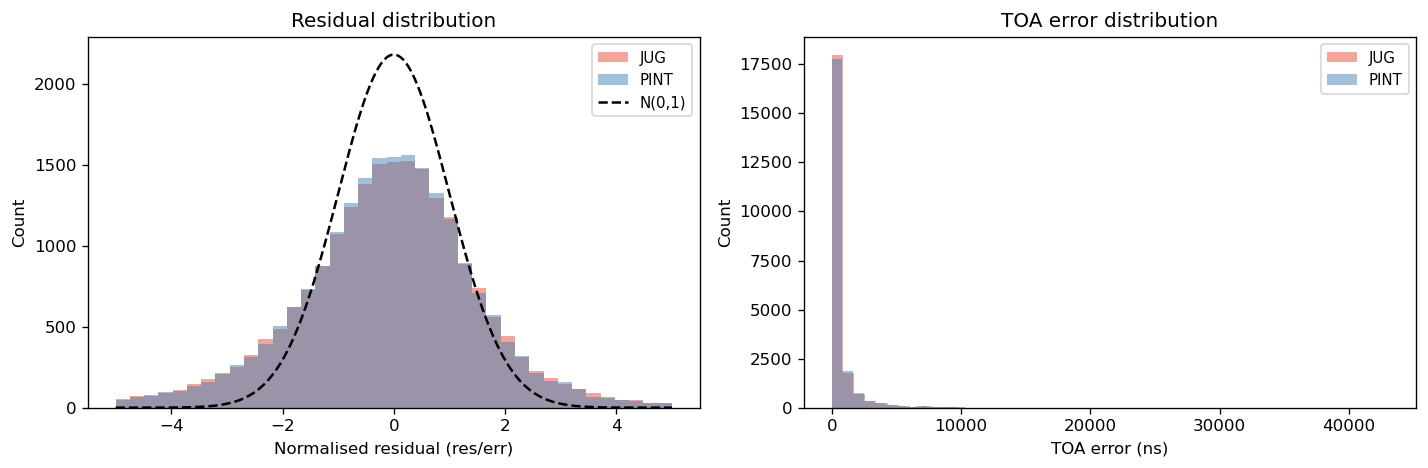

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Normalised residuals (res / err)
ax = axes[0]
if len(jug_err) > 0 and np.all(jug_err > 0):
    norm_jug  = jug_res  / jug_err
    norm_pint = pint_res / pint_err
    bins = np.linspace(-5, 5, 40)
    ax.hist(norm_jug,  bins=bins, alpha=0.5, color='#e74c3c', label='JUG')
    ax.hist(norm_pint, bins=bins, alpha=0.5, color='steelblue', label='PINT')
    # Overplot unit Gaussian
    x = np.linspace(-5, 5, 200)
    from scipy.stats import norm as _norm
    scale = len(norm_jug) * (bins[1] - bins[0])
    ax.plot(x, _norm.pdf(x) * scale, 'k--', lw=1.5, label='N(0,1)')
    ax.legend(fontsize=9)
ax.set_xlabel('Normalised residual (res/err)')
ax.set_ylabel('Count')
ax.set_title('Residual distribution')

# TOA error distribution
ax = axes[1]
ax.hist(jug_err,  bins=50, alpha=0.5, color='#e74c3c', label='JUG')
ax.hist(pint_err, bins=50, alpha=0.5, color='steelblue', label='PINT')
ax.legend(fontsize=9)
ax.set_xlabel('TOA error (ns)')
ax.set_ylabel('Count')
ax.set_title('TOA error distribution')

fig.tight_layout()
plt.show()

## Residuals vs Frequency

2026-04-22 15:44:11.561 | DEBUG    | pint.models.binary_ddk:validate:211 - Validating DDK model in ECL coordinates
2026-04-22 15:44:11.561 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model
2026-04-22 15:44:13.765 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = False)
2026-04-22 15:44:14.176 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-04-22 15:44:14.178 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-04-22 15:44:16.604 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-04-22 15:44:16.605 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-04-22 15:44:17.470 | DEBUG    | pint.toa:compute_posvels:2379 - Computing PosVels of observatories and Earth, using DE440
2026-04-22 15:44:17.601 | INFO     | pint.solar_s

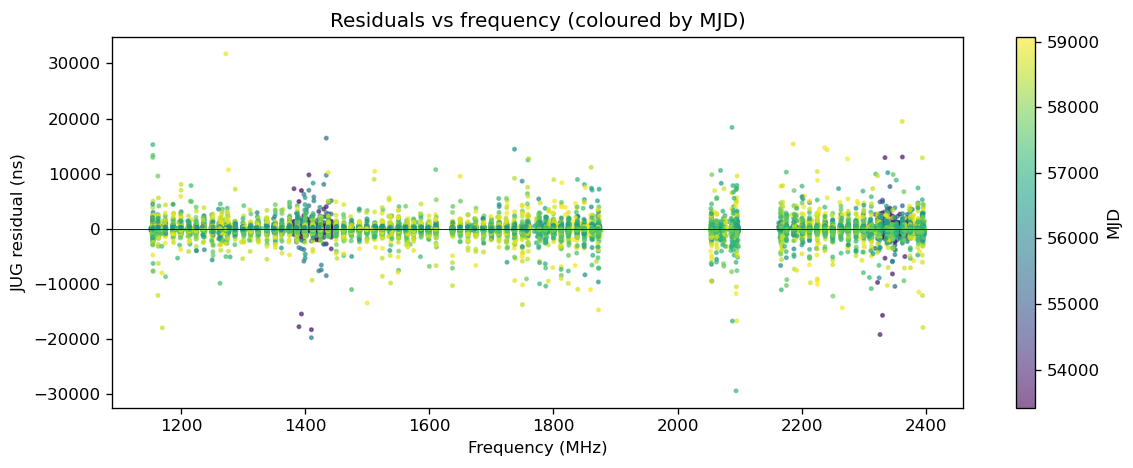

In [16]:
# Try to extract observing frequency from TOAs via PINT
try:
    import pint.toa, pint.models
    _model = pint.models.get_model(str(PAR))
    _toas  = pint.toa.get_TOAs(str(TIM), model=_model,
                                planets=False, include_bipm=False)
    freqs_mhz = _toas.get_freqs().to('MHz').value

    fig, ax = plt.subplots(figsize=(10, 4))
    if len(freqs_mhz) == len(jug_res):
        sc = ax.scatter(freqs_mhz, jug_res, c=jug_mjd, cmap='viridis',
                        s=4, alpha=0.6)
        plt.colorbar(sc, ax=ax, label='MJD')
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xlabel('Frequency (MHz)')
        ax.set_ylabel('JUG residual (ns)')
        ax.set_title('Residuals vs frequency (coloured by MJD)')
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not extract frequencies: {e}')

## Parameter Uncertainty Comparison

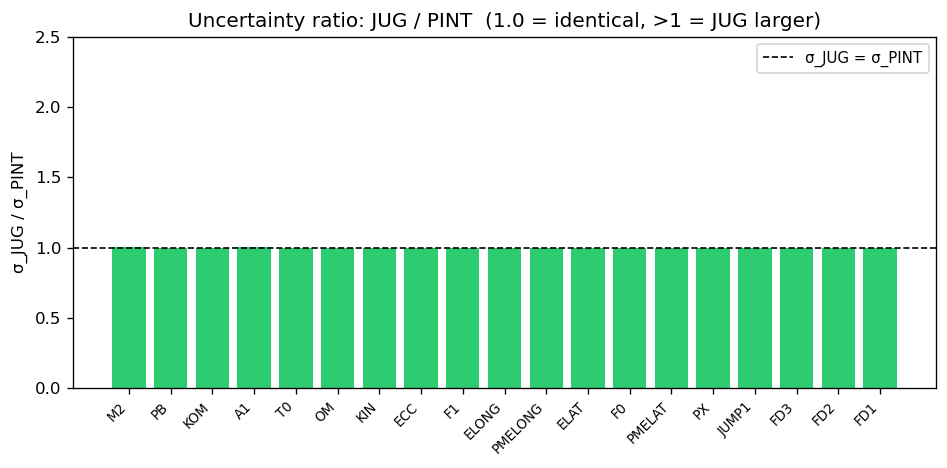

In [17]:
# Ratio of JUG uncertainty to PINT uncertainty for each param
unc_pairs = []
for p in fit_params:
    if p in ANGLE_PARAMS:
        continue
    ju = jug['uncertainties'].get(p, 0.0)
    pu = pint_r['uncertainties'].get(p, 0.0)
    if ju > 0 and pu > 0:
        unc_pairs.append((p, ju, pu, ju / pu))

if unc_pairs:
    unc_pairs.sort(key=lambda x: -abs(np.log10(x[3])))
    labels = [x[0] for x in unc_pairs]
    ratios = [x[3] for x in unc_pairs]

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.3), 4))
    colors = ['#2ecc71' if 0.9 < r < 1.1 else
              '#f39c12' if 0.5 < r < 2.0 else '#e74c3c'
              for r in ratios]
    ax.bar(range(len(labels)), ratios, color=colors)
    ax.axhline(1.0, color='k', lw=1, ls='--', label='σ_JUG = σ_PINT')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('σ_JUG / σ_PINT')
    ax.set_title('Uncertainty ratio: JUG / PINT  (1.0 = identical, >1 = JUG larger)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(2.5, max(ratios) * 1.1))
    fig.tight_layout()
    plt.show()
else:
    print('No uncertainty pairs to compare.')